#0. Dependencies

In [1]:
!pip install dgeb datasets -q
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 19.6 MB/s eta 0:00:00


# 1. Load data from HuggingFace

In [2]:
from datasets import load_dataset

# Dataset Link: https://huggingface.co/tattabio/datasets?p=0
ecoli  = load_dataset("tattabio/ecoli_operonic_pair")
cyano  = load_dataset("tattabio/cyano_operonic_pair")
vibrio = load_dataset("tattabio/vibrio_operonic_pair")

print("E. coli columns:", ecoli["train"].features)
print("Cyano columns:",   cyano["train"].features)
print("Vibrio columns:",  vibrio["train"].features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4315 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/2611 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/344 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/910k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2574 [00:00<?, ? examples/s]

E. coli columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Cyano columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}
Vibrio columns: {'Entry': Value('string'), 'Sequence': Value('string'), 'Label': Value('int64')}


In [3]:

def build_pairs(dataset_split):
    seqs   = dataset_split["Sequence"]
    labels = dataset_split["Label"]

    seq_a, seq_b, pair_labels = [], [], []
    for i in range(len(seqs) - 1):
        seq_a.append(seqs[i])
        seq_b.append(seqs[i + 1])
        pair_labels.append(labels[i])

    return seq_a, seq_b, np.array(pair_labels)

seq_a_ec, seq_b_ec, labels_ec = build_pairs(ecoli["train"])
seq_a_cy, seq_b_cy, labels_cy = build_pairs(cyano["train"])
seq_a_vi, seq_b_vi, labels_vi = build_pairs(vibrio["train"])

print(f"E. coli pairs: {len(labels_ec):,}, positive rate: {labels_ec.mean():.1%}")
print(f"Cyano pairs:   {len(labels_cy):,}, positive rate: {labels_cy.mean():.1%}")
print(f"Vibrio pairs:  {len(labels_vi):,}, positive rate: {labels_vi.mean():.1%}")

E. coli pairs: 4,314, positive rate: 40.5%
Cyano pairs:   2,610, positive rate: 28.2%
Vibrio pairs:  2,573, positive rate: 34.6%


In [4]:
print(ecoli["train"]["Label"][:10])

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


In [5]:
AA = "ACDEFGHIKLMNPQRSTVWY"
KMERS = {"".join(p): i for i, p in enumerate(product(AA, repeat=3))}

def kmer_vector(seq, k=3):
    """Convert amino acid sequence to normalized k-mer frequency vector."""
    vec = np.zeros(len(KMERS), dtype=np.float32)
    seq = seq.upper()
    count = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in KMERS:
            vec[KMERS[kmer]] += 1
            count += 1
    if count > 0:
        vec /= count
    return vec

def encode_pairs(seq_a_list, seq_b_list, label=""):
    print(f"Encoding {label} sequences...")
    vA = np.array([kmer_vector(s) for s in seq_a_list])
    vB = np.array([kmer_vector(s) for s in seq_b_list])
    X  = np.concatenate([vA, vB, np.abs(vA - vB)], axis=1)
    print(f"  Done. Shape: {X.shape}")
    return X

X_ec = encode_pairs(seq_a_ec, seq_b_ec, "E. coli")
X_cy = encode_pairs(seq_a_cy, seq_b_cy, "Cyano")
X_vi = encode_pairs(seq_a_vi, seq_b_vi, "Vibrio")

Encoding E. coli sequences...
  Done. Shape: (4314, 24000)
Encoding Cyano sequences...
  Done. Shape: (2610, 24000)
Encoding Vibrio sequences...
  Done. Shape: (2573, 24000)


In [6]:
from sklearn.model_selection import train_test_split

X_ec_train, X_ec_test, y_ec_train, y_ec_test = train_test_split(
    X_ec, labels_ec, test_size=0.2, stratify=labels_ec, random_state=42
)
X_cy_train, X_cy_test, y_cy_train, y_cy_test = train_test_split(
    X_cy, labels_cy, test_size=0.2, stratify=labels_cy, random_state=42
)
X_vi_train, X_vi_test, y_vi_train, y_vi_test = train_test_split(
    X_vi, labels_vi, test_size=0.2, stratify=labels_vi, random_state=42
)

print(f"E. coli  — train: {X_ec_train.shape[0]:,}  test: {X_ec_test.shape[0]:,}")
print(f"Cyano    — train: {X_cy_train.shape[0]:,}  test: {X_cy_test.shape[0]:,}")
print(f"Vibrio   — train: {X_vi_train.shape[0]:,}  test: {X_vi_test.shape[0]:,}")

E. coli  — train: 3,451  test: 863
Cyano    — train: 2,088  test: 522
Vibrio   — train: 2,058  test: 515


In [7]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.1, 0.5, 1.0]
best_alpha_cnb, best_score_cnb = None, -1

print("CNB hyperparameter search (5-fold CV on E. coli train)")
for alpha in alphas:
    clf = ComplementNB(alpha=alpha)
    scores = cross_val_score(
        clf, X_ec_train, y_ec_train, cv=5, scoring="average_precision"
    )
    mean_ap = scores.mean()
    print(f"  alpha={alpha:.2f}  →  AP={mean_ap:.4f}")
    if mean_ap > best_score_cnb:
        best_score_cnb = mean_ap
        best_alpha_cnb = alpha

print(f"\n Best alpha: {best_alpha_cnb}  (CV AP={best_score_cnb:.4f})")

CNB hyperparameter search (5-fold CV on E. coli train)...
  alpha=0.01  →  AP=0.5297
  alpha=0.10  →  AP=0.4927
  alpha=0.50  →  AP=0.4482
  alpha=1.00  →  AP=0.4361

✓ Best alpha: 0.01  (CV AP=0.5297)


In [8]:
Cs = [0.01, 0.1, 1, 10, 100]
best_C_lr, best_score_lr = None, -1

print("Logistic Regression hyperparameter search (5-fold CV on E. coli train)...")
for C in Cs:
    clf = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                             max_iter=1000, random_state=42)
    scores = cross_val_score(
        clf, X_ec_train, y_ec_train, cv=5, scoring="average_precision"
    )
    mean_ap = scores.mean()
    print(f"  C={C:<6}  →  AP={mean_ap:.4f}")
    if mean_ap > best_score_lr:
        best_score_lr = mean_ap
        best_C_lr = C

print(f"\n Best C: {best_C_lr}  (CV AP={best_score_lr:.4f})")

Logistic Regression hyperparameter search (5-fold CV on E. coli train)...
  C=0.01    →  AP=0.4656
  C=0.1     →  AP=0.5349
  C=1       →  AP=0.5349
  C=10      →  AP=0.5349
  C=100     →  AP=0.5344

✓ Best C: 10  (CV AP=0.5349)


In [9]:
def train_and_evaluate(clf, name):
    """Train on each dataset's train split, evaluate on its own test split."""
    results = {}
    for ds_name, X_train, y_train, X_test, y_test in [
        ("E. coli", X_ec_train, y_ec_train, X_ec_test, y_ec_test),
        ("Cyano",   X_cy_train, y_cy_train, X_cy_test, y_cy_test),
        ("Vibrio",  X_vi_train, y_vi_train, X_vi_test, y_vi_test),
    ]:
        clf.fit(X_train, y_train)
        proba = clf.predict_proba(X_test)[:, 1]
        ap = average_precision_score(y_test, proba)
        results[ds_name] = round(ap, 4)
    return results

cnb_clf = ComplementNB(alpha=best_alpha_cnb)
lr_clf  = LogisticRegression(C=best_C_lr, penalty="l2", solver="lbfgs",
                              max_iter=1000, random_state=42)

cnb_results = train_and_evaluate(cnb_clf, "CNB")
lr_results  = train_and_evaluate(lr_clf,  "LogReg")

print("CNB results:    ", cnb_results)
print("LogReg results: ", lr_results)

CNB results:     {'E. coli': np.float64(0.4884), 'Cyano': np.float64(0.3271), 'Vibrio': np.float64(0.4555)}
LogReg results:  {'E. coli': np.float64(0.5024), 'Cyano': np.float64(0.3204), 'Vibrio': np.float64(0.4636)}


In [10]:
dgeb_baselines = {
    "E. coli": {"ESM2-650M": 0.573, "ESM3": 0.577, "ProtTrans": 0.618},
    "Cyano":   {"ESM2-650M": 0.373, "ESM3": 0.390, "ProtTrans": 0.409},
    "Vibrio":  {"ESM2-650M": 0.483, "ESM3": 0.497, "ProtTrans": 0.543},
}

rows = []
for ds in ["E. coli", "Cyano", "Vibrio"]:
    row = {
        "Dataset":        ds,
        "CNB (ours)":     cnb_results[ds],
        "LogReg (ours)":  lr_results[ds],
        **dgeb_baselines[ds]
    }
    rows.append(row)

df = pd.DataFrame(rows).set_index("Dataset")
print("\n=== Average Precision — Our Methods vs DGEB Baselines ===\n")
print(df.to_string())


=== Average Precision — Our Methods vs DGEB Baselines ===

         CNB (ours)  LogReg (ours)  ESM2-650M   ESM3  ProtTrans
Dataset                                                        
E. coli      0.4884         0.5024      0.573  0.577      0.618
Cyano        0.3271         0.3204      0.373  0.390      0.409
Vibrio       0.4555         0.4636      0.483  0.497      0.543


In [11]:
print(ecoli["train"]["Label"][:10])

[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


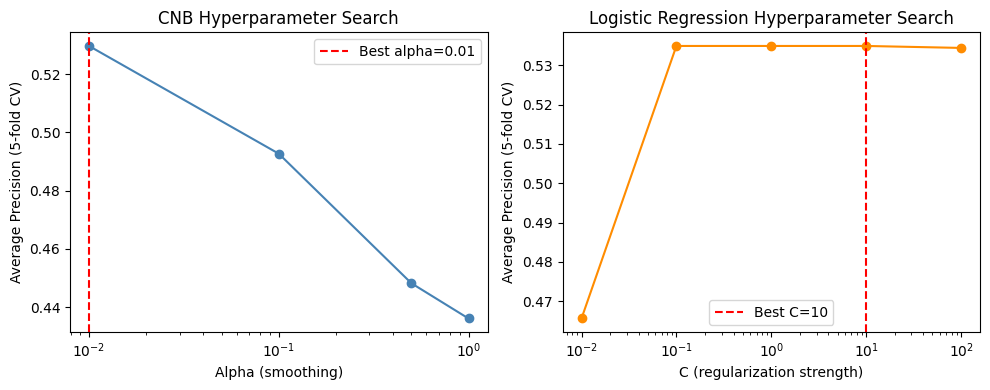

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# CNB
alphas = [0.01, 0.1, 0.5, 1.0]
cnb_aps = [0.5297, 0.4927, 0.4482, 0.4361]
ax1.plot(alphas, cnb_aps, marker='o', color='steelblue')
ax1.axvline(x=0.01, linestyle='--', color='red', label='Best alpha=0.01')
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (smoothing)')
ax1.set_ylabel('Average Precision (5-fold CV)')
ax1.set_title('CNB Hyperparameter Search')
ax1.legend()

# LogReg
Cs = [0.01, 0.1, 1, 10, 100]
lr_aps = [0.4656, 0.5349, 0.5349, 0.5349, 0.5344]
ax2.plot(Cs, lr_aps, marker='o', color='darkorange')
ax2.axvline(x=10, linestyle='--', color='red', label='Best C=10')
ax2.set_xscale('log')
ax2.set_xlabel('C (regularization strength)')
ax2.set_ylabel('Average Precision (5-fold CV)')
ax2.set_title('Logistic Regression Hyperparameter Search')
ax2.legend()

plt.tight_layout()
plt.savefig('hyperparameter_search.png', dpi=150)
plt.show()

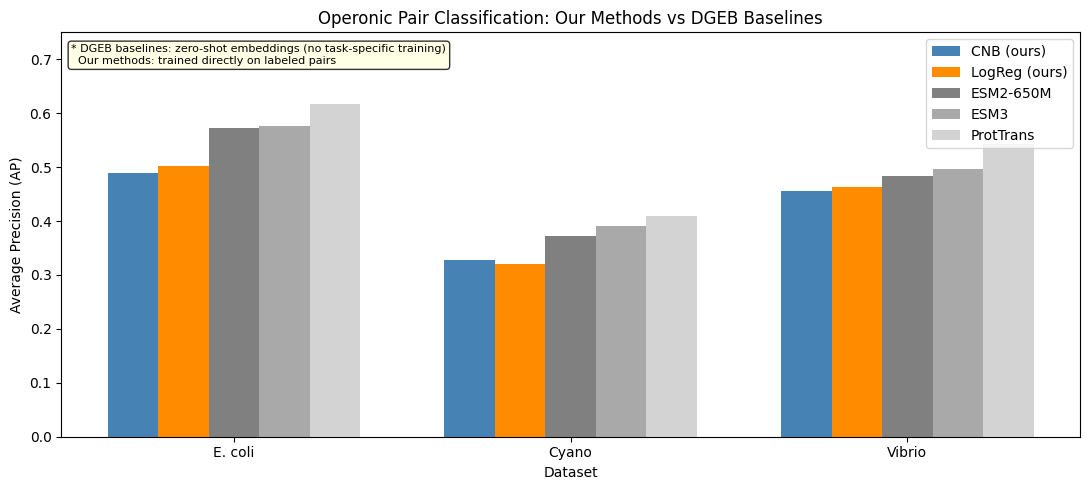

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

datasets = ['E. coli', 'Cyano', 'Vibrio']
methods = {
    'CNB (ours)':    [0.4884, 0.3271, 0.4555],
    'LogReg (ours)': [0.5024, 0.3204, 0.4636],
    'ESM2-650M':     [0.573,  0.373,  0.483],
    'ESM3':          [0.577,  0.390,  0.497],
    'ProtTrans':     [0.618,  0.409,  0.543],
}

x = np.arange(len(datasets))
width = 0.15
colors = ['steelblue', 'darkorange', 'gray', 'darkgray', 'lightgray']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (method, values) in enumerate(methods.items()):
    ax.bar(x + i * width, values, width, label=method, color=colors[i])

ax.set_xlabel('Dataset')
ax.set_ylabel('Average Precision (AP)')
ax.set_title('Operonic Pair Classification: Our Methods vs DGEB Baselines')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 0.75)
ax.legend(loc='upper right')

ax.text(0.01, 0.97,
        '* DGEB baselines: zero-shot embeddings (no task-specific training)\n'
        '  Our methods: trained directly on labeled pairs',
        transform=ax.transAxes, fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()